In [3]:
import time
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d, spinless_fermion_basis_1d, ho_basis, tensor_basis, boson_basis_1d
from quspin.tools.evolution import evolve
import scipy.sparse.linalg as splinalg  
from scipy import sparse
import matplotlib.pyplot as plt
import qutip as qt
from tqdm import tqdm 
from matplotlib.colors import LinearSegmentedColormap

### ----------------------------------------------------------

In [14]:
# Electron-phonon coupling function L=1------------------------------------
def g():
    return (1/np.pi)*(1-np.cos(np.pi))

In [15]:
def equalsuperpositionofdegeneratestates(E_GS,psi_GS_):
    # Manually creating Superposition of degenerate states for GS
    sorted_indices = np.argsort(E_GS)
    E_GS = E_GS[sorted_indices]
    psi_GS_ = psi_GS_[:, sorted_indices]

    E = np.around(E_GS[0], decimals=5)
    index_E = next((i for i in range(len(E_GS)) if E != np.around(E_GS[i], decimals=5)), None)
    #print(index_E)
    psi_GS = np.sum(psi_GS_.T[:index_E], axis=0) / np.sqrt(index_E)
    return psi_GS

#### Equilibrium

In [16]:
# Used Operators in Hamiltonian------------------------------------------
def double_occupation(basis_electron_phonon,L):
    # nr of double occu per tube on average
    electron_number_operator_ep_A = hamiltonian(
        [
            ['n|n|||', [[0.5, i, i] for i in range(L)]],
            ['||n|n|', [[0.5, i, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return electron_number_operator_ep_A


def total_number_electrons(basis_electron_phonon,L):
    total_number_electrons = hamiltonian(
        [
            ['n||||', [[1, i] for i in range(L)]],
            ['|n|||', [[1, i] for i in range(L)]],
            ['||n||', [[1, i] for i in range(L)]],
            ['|||n|', [[1, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return total_number_electrons

def phonon_number_operator(basis_electron_phonon):
    # avg phonon number in the tubes
    phonon_number_operator = hamiltonian(
        [
            ['||||n', [[0.5, 0]]],
            ['||||n', [[0.5, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_number_operator

def phonon_a_operator_A(basis_electron_phonon):
    phonon_a_operator_A = hamiltonian(
        [
            ['||||-', [[1, 0]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_a_operator_A

def phonon_a_operator_B(basis_electron_phonon):
    phonon_a_operator_B = hamiltonian(
        [
            ['||||-', [[1, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_a_operator_B

def phonon_adag_operator_A(basis_electron_phonon):
    phonon_adag_operator_A = hamiltonian(
        [
            ['||||+', [[1, 0]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_adag_operator_A

def phonon_adag_operator_B(basis_electron_phonon):
    phonon_adag_operator_B = hamiltonian(
        [
            ['||||+', [[1, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_adag_operator_B

# Charge Correlation: Inside one Tube--------------------------------
def charge_corr_singletube(basis_electron_phonon, psi_GS,L):
    def charge_single(i):
        h = hamiltonian(
            [
                # Number operator
                ['n||||', [[0.5, i]]],
                ['|n|||', [[0.5, i]]],
                ['||n||', [[0.5, i]]],
                ['|||n|', [[0.5, i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return h

    def charge_both_single(i,j):
        h = hamiltonian(
            [
                # Number operator
                ['nn||||', [[0.5, i,j]]],
                ['|nn|||', [[0.5, i,j]]],
                ['n|n|||', [[0.5, i,j]]],
                ['n|n|||', [[0.5, j,i]]],
                ['||nn||', [[0.5, i,j]]],
                ['|||nn|', [[0.5, i,j]]],
                ['||n|n|', [[0.5, i,j]]],
                ['||n|n|', [[0.5, j,i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return h
    
    CC_single = 0
    for i in range(L):
        for j in range(i+1):
            CC_single += np.real(charge_both_single(i,j).expt_value(psi_GS)-charge_single(i).expt_value(psi_GS)*charge_single(j).expt_value(psi_GS))
    return CC_single

# Charge Correlation: Between Tubes ----------------------------------
def charge_corr_between(basis_electron_phonon, psi_GS,L):
    def charge_both_dT(i,j): #first index: Tube1, second Index: Tube 2
        op = hamiltonian(
            [
                ['n||n||', [[1, i, j]]],
                ['n|||n|', [[1, i, j]]],
                ['|n|n||', [[1, i, j]]],
                ['|n||n|', [[1, i, j]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return op
        
    def charge_dt(m,i): #m: Index of Tube{0,1}; i: Index of Site
        if m == 0:
            op = hamiltonian(
                [
                    ['n||||', [[1, i]]],
                    ['|n|||', [[1, i]]],
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
            return op
        op = hamiltonian(
            [
                ['||n||', [[1, i]]],
                ['|||n|', [[1, i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return op

    CC_dT = 0
    for i in range(L): #Tube1
        for j in range(L): #Tube2
            CC_dT += np.real(charge_both_dT(i,j).expt_value(psi_GS)-charge_dt(0,i).expt_value(psi_GS)*charge_dt(1,j).expt_value(psi_GS))
    return CC_dT

In [17]:
def hamiltonian_noshift(omega, epsilon, U, V, g0,L,basis_electron_phonon):
    H = hamiltonian(
        [
            ## phonon part
            ["||||n", [[omega, 0]]],
            ["||||n", [[omega, 1]]],
            ## electron part
            # onsite energy - Tube A
            ['n|n|||', [[U, i, i] for i in range(L)]],
            # onsite energy - Tube B
            ['||n|n|', [[U, i, i] for i in range(L)]],
            # chemical potential A
            ['n||||', [[epsilon, i] for i in range(L)]],
            ['|n|||', [[epsilon, i] for i in range(L)]],
            # chemical potential B
            ['||n||', [[epsilon, i] for i in range(L)]],
            ['|||n|', [[epsilon, i] for i in range(L)]],

            # inter-tube coupling
            # Coulomb-Interaction between Tubes
            ['n||n||', [[V, i, i] for i in range(L)]],
            ['n|||n|', [[V, i, i] for i in range(L)]],
            ['|n|n||', [[V, i, i] for i in range(L)]],
            ['|n||n|', [[V, i, i] for i in range(L)]],

            ## electron-phonon coupling
            ## electron-phonon coupling
            # Tube A
            ['n||||+', [[g()*g0, i, 0] for i in range(L)]],
            ['n||||-', [[g()*g0, i, 0] for i in range(L)]],
            ['|n|||+', [[g()*g0, i, 0] for i in range(L)]],
            ['|n|||-', [[g()*g0, i, 0] for i in range(L)]],
            # Tube B
            ['||n||+', [[g()*g0, i, 1] for i in range(L)]],
            ['||n||-', [[g()*g0, i, 1] for i in range(L)]],
            ['|||n|+', [[g()*g0, i, 1] for i in range(L)]],
            ['|||n|-', [[g()*g0, i, 1] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return H

In [18]:
def noshift_method(L, max_phonon_nr, model_params):  
    # extract model params
    omega, epsilon, U, V, g0 = (model_params.get(key, 0) for key in ['omega', 'epsilon', 'U', 'V', 'g0'])

    # Basis-----------------------------------------------------
    basis_electron = spinless_fermion_basis_1d(L=L) 
    basis_phonon = boson_basis_1d(L=2,sps = max_phonon_nr)
    basis_electron_phonon = tensor_basis(basis_electron, basis_electron,basis_electron,basis_electron, basis_phonon)
    #print(basis_electron_phonon)

    # Build Hamiltonian and determine GS------------------------
    H = hamiltonian_noshift(omega, epsilon, U, V, g0,L,basis_electron_phonon)
    E_GS, psi_GS_ = H.eigh()
    psi_GS = equalsuperpositionofdegeneratestates(E_GS, psi_GS_)
    # E_GS, psi_GS = H.eigsh(k=1, which='SA', tol= 1e-12, maxiter=100000)
    # psi_GS = psi_GS.T[0]

    ## MEASUREMENTS-------------------------------------------------
    # Double Occupation of Electrons
    double_occupation_A = double_occupation(basis_electron_phonon,L).expt_value(psi_GS)

    # Total number of Electrons
    total_electrons = total_number_electrons(basis_electron_phonon,L).expt_value(psi_GS)

    # Phononnumbers
    phonon_nr = phonon_number_operator(basis_electron_phonon).expt_value(psi_GS)

    # Charge Correlation: Inside one Tube
    CC_single = charge_corr_singletube(basis_electron_phonon, psi_GS, L)

    # Charge Correlation: Between Tubes 
    #CC_dt = charge_corr_between(basis_electron_phonon, psi_GS, L)
    

    return double_occupation_A, total_electrons, phonon_nr, CC_single,0,0,0,0

In [19]:
# Operators needed ----

# Fermi-Dirac distribution
def Fermi_Dirac(e,mu,T):
    return 1 / (np.exp((e - mu) / T) + 1)

# jump operators
def lindblad_operator_eigen(creation_operator, Es, psis, mu, T, DoS_F, coupling, band_width):
    creation = np.matmul(np.transpose(np.conjugate(psis)), np.matmul(creation_operator.toarray(), psis))
    Lp = np.sqrt(2 * np.pi * DoS_F * Fermi_Dirac(np.subtract.outer(Es, Es),mu,T)) * coupling * creation * ((-band_width < np.subtract.outer(Es, Es)) * (np.subtract.outer(Es, Es) < band_width))
    Lm = np.sqrt(2 * np.pi * DoS_F * (1 - Fermi_Dirac(-np.subtract.outer(Es, Es),mu,T))) * coupling * np.transpose(np.conjugate(creation)) * ((-band_width < np.subtract.outer(Es, Es)) * (np.subtract.outer(Es, Es) < band_width))
    return Lp, Lm

# build up the Pauli master operator in the eigenstate basis
def pauli_op(Ls_eigen):
    P_eigen = np.zeros(Ls_eigen[0].shape, dtype=np.complex128)
    for jump_operator in Ls_eigen:
        P_eigen += jump_operator * jump_operator.conj()
        D_eigen = np.sum(jump_operator * jump_operator.conj(), axis=0)
        P_eigen -= np.diag(D_eigen)
    P_eigen = np.real(P_eigen)
    return P_eigen

# calculate the Pauli initial guess by solving the equation Px = y in the eigenstate basis
def apply_pauli_master_equation_eigen(P_eigen,x):
    """
    In-place update of y = Px, where P and x are the Pauli master equation operator and the diagonal populations. y[0] is set to the sum of the polulations so as to enforce a normalized nontrivial solution.
    """
    x_p = x[1:]
    y = np.zeros((P_eigen.shape[0] + 1))
    y[0] = np.sum(x_p)
    y[1:] = P_eigen @ x_p

    return y

def electron_creation_operator_A_up(basis_electron_phonon):
    electron_creation_operator = hamiltonian(
                [
                    ['+||||', [[1, 0]]]
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
    return electron_creation_operator

def electron_creation_operator_A_dn(basis_electron_phonon):
    electron_creation_operator = hamiltonian(
                [
                    ['|+|||', [[1, 0]]]
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
    return electron_creation_operator

def electron_creation_operator_B_up(basis_electron_phonon):
    electron_creation_operator = hamiltonian(
                [
                    ['||+||', [[1, 0]]]
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
    return electron_creation_operator

def electron_creation_operator_B_dn(basis_electron_phonon):
    electron_creation_operator = hamiltonian(
                [
                    ['|||+|', [[1, 0]]]
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
    return electron_creation_operator

def electron_number_A(basis_electron_phonon):
    electron_creation_operators = hamiltonian(
                [
                    ['n||||', [[1, 0]]],
                    ['|n|||', [[1, 0]]],
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
    return electron_creation_operators

def electron_number_B(basis_electron_phonon):
    electron_creation_operators = hamiltonian(
                [
                    ['||n||', [[1, 0]]],
                    ['|||n|', [[1, 0]]],
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
    return electron_creation_operators

#### Pauli Master

In [8]:
def pauli_master_method(L, max_phonon_nr, model_params,lead_params):  
    # extract model params
    omega, epsilon, U, V, g0 = (model_params.get(key, 0) for key in ['omega', 'epsilon', 'U', 'V', 'g0'])
    muL = lead_params.get('muL', 0)
    muR = lead_params.get('muR', 0)
    T = lead_params.get('T', 0)
    DoS_F = lead_params.get('DoS_F', 0)
    coupling = lead_params.get('coupling', 0)
    band_width = lead_params.get('band_width', 0)

    # Basis-----------------------------------------------------
    basis_electron = spinless_fermion_basis_1d(L=L) 
    basis_phonon = boson_basis_1d(L=2,sps = max_phonon_nr)
    basis_electron_phonon = tensor_basis(basis_electron, basis_electron,basis_electron,basis_electron, basis_phonon)

    # Build Hamiltonian and determine full eigen spectrum------------------------
    H = hamiltonian_noshift(omega, epsilon, U, V, g0,L,basis_electron_phonon)
    Es, psis = H.eigh()
    H = H.toarray()

    # sort the eigen states first by electron number then by phonon number
    phononnr_eigen = []
    electronnr_eigen = []
    for i in range(len(Es)):
        phononnr_eigen.append(phonon_number_operator(basis_electron_phonon).expt_value(psis[:, i]))
        electronnr_eigen.append(0.5*total_number_electrons(basis_electron_phonon,L).expt_value(psis[:, i]))

    idx = list(np.lexsort((phononnr_eigen, np.around(electronnr_eigen))))
    Es = np.asarray(Es)[idx]
    psis = psis[:, idx]

    # build the jump operators in the eigenstate basis for both spins and both tubes
    creation_operators = [
        electron_creation_operator_A_up(basis_electron_phonon),
        electron_creation_operator_A_dn(basis_electron_phonon),
        electron_creation_operator_B_up(basis_electron_phonon),
        electron_creation_operator_B_dn(basis_electron_phonon),
    ]

    Ls_eigen = []
    current_operator_eigen = np.zeros_like(H, dtype=np.complex128)
    for creation_operator in creation_operators:
        LpL_eigen, LmL_eigen = lindblad_operator_eigen(creation_operator, Es, psis, muL, T, DoS_F, coupling, band_width)
        LpR_eigen, LmR_eigen = lindblad_operator_eigen(creation_operator, Es, psis, muR, T, DoS_F, coupling, band_width)
        Ls_eigen.extend([LpL_eigen, LmL_eigen, LpR_eigen, LmR_eigen])
        current_operator_eigen += LpL_eigen.conj().T @ LpL_eigen - LmL_eigen.conj().T @ LmL_eigen
    current_operator_eigen *= 0.5

    # electrical current operator
    current_operator_fock = np.matmul(psis, np.matmul(current_operator_eigen, np.transpose(np.conjugate(psis))))
    
    # build pauli operator
    P_eigen = pauli_op(Ls_eigen)

    # calculate the Pauli initial guess by solving the equation Px = y in the eigenstate basis
    def apply_pauli_master_equation_eigen(x):
        """
        In-place update of y = Px, where P and x are the Pauli master equation operator and the diagonal populations. y[0] is set to the sum of the polulations so as to enforce a normalized nontrivial solution.
        """
        x_p = x[1:]
        y = np.zeros((P_eigen.shape[0] + 1))
        y[0] = np.sum(x_p)
        y[1:] = P_eigen @ x_p

        return y
    
    pauli_eigen = splinalg.LinearOperator(tuple(s + 1 for s in P_eigen.shape), matvec=apply_pauli_master_equation_eigen)

    # use the lowest eigenstate as initial guess
    x0_pauli_eigen = np.zeros((P_eigen.shape[0] + 1))
    x0_pauli_eigen[np.argmin(Es) + 1] = 1

    y_pauli_eigen = np.zeros((P_eigen.shape[0] + 1))
    y_pauli_eigen[0] = 1

    x_pauli_eigen, info_pauli_eigen = splinalg.lgmres(pauli_eigen, y_pauli_eigen, x0=x0_pauli_eigen, rtol=1e-10, maxiter=2500, atol=1e-10)

    rho0_eigen = np.diag(x_pauli_eigen[1:])

    # eigenstate basis -> fock basis
    rho0_fock = np.matmul(psis, np.matmul(rho0_eigen, np.transpose(np.conjugate(psis))))
    rho0_fock = rho0_fock / np.trace(rho0_fock) 
    
    
    ## MEASUREMENTS-------------------------------------------------
    # Double Occupation of Electrons
    double_occupation_A = double_occupation(basis_electron_phonon,L).expt_value(rho0_fock)

    # Total number of Electrons
    total_electrons = total_number_electrons(basis_electron_phonon,L).expt_value(rho0_fock)

    # Phononnumbers
    phonon_nr = phonon_number_operator(basis_electron_phonon).expt_value(rho0_fock)

    # Number of Electrons in single tube
    e_A = electron_number_A(basis_electron_phonon).expt_value(rho0_fock)
    e_B = electron_number_B(basis_electron_phonon).expt_value(rho0_fock)

    # Avg Current in a single tube
    current = np.real(np.trace(current_operator_fock @ rho0_fock))
    

    return double_occupation_A, total_electrons, phonon_nr, e_A, e_B, current,0,0

##### Simulation

In [9]:
# Setting up parameters of the system
''' Parameters
    - L:   number of QDs per tube
    - N:   number of electrons of each spin per tube
    - o_s: fundamental frequency of phonons
    - t_s: tunnenling amplitudes of electrons
    - max_shifted_phonon_number: number of respected phononic excited states
    - factor: ration of U/g_0
    - V_over_U: rescaled inter-tube coupling potential
    - mu: integer corresponding to chosen mode
'''
L = 1                                   
omega = 1 # 100 MHz
g0s = np.linspace(0.5,0.5,num=1)# 10-100 MHz
mu = 1
U = 2 # GHz
V = 0.1*U # GHz
epsilons = np.array([0.3])*U#np.arange(-1/3, 1/3, 0.01)*U # GHz

print("Lambda: ", g0s[0]**2/(omega*U), g0s[-1]**2/(omega*U))

# Lead parameters
bias = 80
tunneling_rate = 0.001*U
coupling = np.sqrt(tunneling_rate / (2*np.pi))
muL = 0.5 * bias
muR = -0.5 * bias
T = 2.0
DoS_F = 1
band_width = 15000
             

max_phonon_nr = 25



Lambda:  0.125 0.125


In [10]:
g0s**2/(omega*U)

array([0.125])

In [11]:
# Setup of Containers
double_occu = np.zeros((len(epsilons), len(g0s)))
totalnumberofelectrons = np.zeros((len(epsilons), len(g0s)))
phonon_numb = np.zeros((len(epsilons), len(g0s)))
electrons_A = np.zeros((len(epsilons), len(g0s)))
electrons_B = np.zeros((len(epsilons), len(g0s)))
current = np.zeros((len(epsilons), len(g0s)))
MI_phonons = np.zeros((len(epsilons), len(g0s)))
negativity = np.zeros((len(epsilons), len(g0s)))

In [ ]:
# Iteration of different system setups
for index1, i in enumerate(tqdm(g0s)):
    for index2, j in enumerate(epsilons):
        model_params = {
            'omega': omega,
            'epsilon': j,
            'U': U,
            'V': V,
            'g0': i,
        }
        lead_params = {
            'bias': bias,
            'tunneling_rate': tunneling_rate,
            'coupling': coupling,
            'muL': muL,
            'muR': muR,
            'T': T,
            'DoS_F': DoS_F,
            'band_width': band_width,
        }
        output1, output2, output3, output4, output5, output6, output7, output8 = pauli_master_method(L, max_phonon_nr, model_params, lead_params)

        double_occu[len(epsilons)-1-index2][index1] = output1
        totalnumberofelectrons[len(epsilons)-1-index2][index1] = output2
        phonon_numb[len(epsilons)-1-index2][index1] = output3
        electrons_A[len(epsilons)-1-index2][index1] = output4
        electrons_B[len(epsilons)-1-index2][index1] = output5
        current[len(epsilons)-1-index2][index1] = output6
        MI_phonons[len(epsilons)-1-index2][index1] = output7
        negativity[len(epsilons)-1-index2][index1] = output8
        #break
    #break


  0%|          | 0/1 [00:00<?, ?it/s]

In [80]:
totalnumberofelectrons

array([[1.99999999]])

In [81]:
double_occu

array([[0.25]])

In [82]:
electrons_A

array([[1.]])

In [83]:
electrons_B

array([[1.]])

In [84]:
phonon_numb

array([[6.99997892]])

In [85]:
current

array([[0.002]])

In [86]:
current

array([[0.002]])

In [60]:
g0s**2/(omega*U)

array([0.        , 0.01580247, 0.06320988, 0.14222222, 0.25283951,
       0.39506173, 0.56888889, 0.77432099, 1.01135802, 1.28      ])

#### Lindblad

In [20]:
def lindblad_operator_eigen_fock(creation_operator, Es, psis, mu, T, DoS_F, coupling, band_width):

    # operators in eigenstate basis
    creation = np.matmul(np.transpose(np.conjugate(psis)), np.matmul(creation_operator.toarray(), psis))
    Lp_eigen = np.sqrt(2 * np.pi * DoS_F * Fermi_Dirac(np.subtract.outer(Es, Es),mu,T)) * coupling * creation * ((-band_width < np.subtract.outer(Es, Es)) * (np.subtract.outer(Es, Es) < band_width))
    Lm_eigen = np.sqrt(2 * np.pi * DoS_F * (1 - Fermi_Dirac(-np.subtract.outer(Es, Es),mu,T))) * coupling * np.transpose(np.conjugate(creation)) * ((-band_width < np.subtract.outer(Es, Es)) * (np.subtract.outer(Es, Es) < band_width))

    # eigenstate basis -> original basis; we work in the original basis instead of eigenstate basis
    Lp_fock = np.matmul(psis, np.matmul(Lp_eigen, np.transpose(np.conjugate(psis))))
    Lm_fock = np.matmul(psis, np.matmul(Lm_eigen, np.transpose(np.conjugate(psis))))

    return Lp_eigen, Lm_eigen, Lp_fock, Lm_fock


def lindblad_master_equation(time_, rho_, H_, Ls_):
    rho_ = rho_.reshape(H_.shape)
    rho_out = -1.j * H_ @ rho_
    rho_out -= -1.j * rho_ @ H_
    for L in Ls_:
        rho_out += L @ (rho_ @ L.T.conj())
        rho_out -= 0.5 * rho_ @ (L.T.conj() @ L)
        rho_out -= 0.5 * (L.T.conj() @ L) @ rho_
    return rho_out.ravel()

In [41]:
def lindblad_solver(L, max_phonon_nr, model_params,lead_params):  
    # extract model params
    omega, epsilon, U, V, g0 = (model_params.get(key, 0) for key in ['omega', 'epsilon', 'U', 'V', 'g0'])
    muL = lead_params.get('muL', 0)
    muR = lead_params.get('muR', 0)
    T = lead_params.get('T', 0)
    DoS_F = lead_params.get('DoS_F', 0)
    coupling = lead_params.get('coupling', 0)
    band_width = lead_params.get('band_width', 0)

    # Basis-----------------------------------------------------
    basis_electron = spinless_fermion_basis_1d(L=L) 
    basis_phonon = boson_basis_1d(L=2,sps = max_phonon_nr)
    basis_electron_phonon = tensor_basis(basis_electron, basis_electron,basis_electron,basis_electron, basis_phonon)

    # Build Hamiltonian and determine full eigen spectrum------------------------
    H = hamiltonian_noshift(omega, epsilon, U, V, g0,L,basis_electron_phonon)
    Es, psis = H.eigh()
    gs = equalsuperpositionofdegeneratestates(Es, psis)
    H = H.toarray()

    # sort the eigen states first by electron number then by phonon number
    phononnr_eigen = []
    electronnr_eigen = []
    for i in range(len(Es)):
        phononnr_eigen.append(phonon_number_operator(basis_electron_phonon).expt_value(psis[:, i]))
        electronnr_eigen.append(0.5*total_number_electrons(basis_electron_phonon,L).expt_value(psis[:, i]))

    idx = list(np.lexsort((phononnr_eigen, np.around(electronnr_eigen))))
    Es = np.asarray(Es)[idx]
    psis = psis[:, idx]

    # build the jump operators in the eigenstate basis for both spins and both tubes
    creation_operators = [
        electron_creation_operator_A_up(basis_electron_phonon),
        electron_creation_operator_A_dn(basis_electron_phonon),
        electron_creation_operator_B_up(basis_electron_phonon),
        electron_creation_operator_B_dn(basis_electron_phonon),
    ]

    Ls_eigen = []
    Ls_fock = []
    current_operator = np.zeros_like(H, dtype=np.complex128)
    for creation_operator in creation_operators:
        LpL_eigen, LmL_eigen, LpL_fock, LmL_fock = lindblad_operator_eigen_fock(creation_operator, Es, psis, muL, T, DoS_F, coupling, band_width)
        LpR_eigen, LmR_eigen, LpR_fock, LmR_fock = lindblad_operator_eigen_fock(creation_operator, Es, psis, muR, T, DoS_F, coupling, band_width)
        Ls_eigen.extend([LpL_eigen, LmL_eigen, LpR_eigen, LmR_eigen])
        Ls_fock.extend([LpL_fock, LmL_fock, LpR_fock, LmR_fock])
        current_operator += LpL_fock.conj().T @ LpL_fock - LmL_fock.conj().T @ LmL_fock
    current_operator *= 0.5

    # initial state: GS of the H closed
    rho0_fock = np.outer(gs,gs.conj())
    # parameters to control the steady state solver 
    max_iter_quspin = 1000
    quspin_times = np.array([0,10])

    iter_quspin = 0
    current_error = np.inf
    state_error = np.inf
    residual_error = np.inf
    state_error_tol = 1.e-5
    residual_error_tol = 1.e-5
    currents_ = [np.real(np.trace(current_operator @ rho0_fock))]
    print("Time evolution starts!")
    while iter_quspin < max_iter_quspin and current_error > 1e-4:#(state_error > state_error_tol or residual_error > residual_error_tol):
        time_quspin_evolve_start = time.time()
        rho_quspin = evolve(rho0_fock, quspin_times[0], quspin_times, lindblad_master_equation, f_params=(H, Ls_fock), iterate=False, atol=1e-8, rtol=1e-8)
        time_quspin_evolve_end = time.time()
        rho1_fock = rho_quspin[:, :, 1]
        rho1_fock = 0.5 * (rho1_fock + rho1_fock.conj().T)
        rho1_fock = rho1_fock / np.trace(rho1_fock)

        delta_rho = rho1_fock - rho0_fock
        delta_rho = 0.5 * (delta_rho + delta_rho.conj().T)
        state_error = 0.5 * np.sum(np.abs(np.linalg.eigvalsh(delta_rho)))
        residual = lindblad_master_equation(0, rho1_fock.ravel(), H, Ls_fock).reshape(H.shape)
        residual_error = np.linalg.norm(residual, ord="nuc")

        if len(currents_) < 5:
            currents_.append(np.real(np.trace(current_operator @ rho1_fock)))
            current_error = np.std(currents_)
        else:
            currents_.pop(0)
            currents_.append(np.real(np.trace(current_operator @ rho1_fock)))
            current_error = np.std(currents_)

        # measurements
        # Total number of Electrons
        total_electrons = np.real(total_number_electrons(basis_electron_phonon,L).expt_value(rho1_fock))

        # Phononnumbers
        phonon_nr = np.real(phonon_number_operator(basis_electron_phonon).expt_value(rho1_fock))

        # Number of Electrons in single tube
        e_A = np.real(electron_number_A(basis_electron_phonon).expt_value(rho1_fock))
        e_B = np.real(electron_number_B(basis_electron_phonon).expt_value(rho1_fock))

        # Avg Current in a single tube
        current = np.real(np.trace(current_operator @ rho1_fock))

        print(f"Phonon number after {iter_quspin} steps of time evolution: {phonon_nr}")
        print(f"Electron number after {iter_quspin} steps of time evolution: {np.real(total_electrons)}")
        print(f"Electron number in A,B after {iter_quspin} steps of time evolution: {(e_A,e_B)}")
        print(f"Current after {iter_quspin} steps of time evolution: {current}")
        print(f"Current error: {current_error}")
        print(f"Trace distance error: {state_error}")
        print(f"Lindblad residual error: {residual_error}; take {time_quspin_evolve_end-time_quspin_evolve_start:.2f}s")


        rho0_fock = rho1_fock
        iter_quspin += 1

    rho = rho1_fock
    return total_electrons, phonon_nr, e_A, e_B, current, 0, 0

### ----------------------------------------------------------

#### Simulation

In [42]:
# Setting up parameters of the system
''' Parameters
    - L:   number of QDs per tube
    - N:   number of electrons of each spin per tube
    - o_s: fundamental frequency of phonons
    - t_s: tunnenling amplitudes of electrons
    - max_shifted_phonon_number: number of respected phononic excited states
    - factor: ration of U/g_0
    - V_over_U: rescaled inter-tube coupling potential
    - mu: integer corresponding to chosen mode
'''

L = 1                                   
omega = 1 # 100 MHz
U = 2 # GHz
l = np.linspace(0.1,0.1,num=1)
g0s = np.sqrt(l*(omega*U)) # 10-100 MHz
mu = 1
V = U # GHz
epsilons = np.array([0.05])*U#np.arange(-1/3, 1/3, 0.01)*U # GHz

print("Lambda: ", g0s[0]**2/(omega*U), g0s[-1]**2/(omega*U))

# Lead parameters
bias = 0.8 #should approx one magnitude less than the on-site potential
tunneling_rate =0.01*U
coupling = np.sqrt(tunneling_rate / (2*np.pi))
muL = 0.5 * bias
muR = -0.5 * bias
T = 2.0*tunneling_rate
DoS_F = 1
band_width = 15000


max_phonon_nr = 4



Lambda:  0.09999999999999999 0.09999999999999999


In [43]:
g0s**2/(omega*U)

array([0.1])

In [44]:
# Setup of Containers
totalnumberofelectrons_LB = np.zeros((len(epsilons), len(g0s)))
phonon_numb_LB = np.zeros((len(epsilons), len(g0s)))
electrons_A_LB = np.zeros((len(epsilons), len(g0s)))
electrons_B_LB = np.zeros((len(epsilons), len(g0s)))
current_LB = np.zeros((len(epsilons), len(g0s)))
MI_phonons = np.zeros((len(epsilons), len(g0s)))
negativity = np.zeros((len(epsilons), len(g0s)))

In [45]:
# Iteration of different system setups
for index1, i in enumerate(tqdm(g0s)):
    for index2, j in enumerate(epsilons):
        model_params = {
            'omega': omega,
            'epsilon': j,
            'U': U,
            'V': V,
            'g0': i,
        }
        lead_params = {
            'bias': bias,
            'tunneling_rate': tunneling_rate,
            'coupling': coupling,
            'muL': muL,
            'muR': muR,
            'T': T,
            'DoS_F': DoS_F,
            'band_width': band_width,
        }
        output1, output2, output3, output4, output5, output6, output7 = lindblad_solver(L, max_phonon_nr, model_params, lead_params)

        totalnumberofelectrons_LB[len(epsilons)-1-index2][index1] = output1
        phonon_numb_LB[len(epsilons)-1-index2][index1] = output2
        electrons_A_LB[len(epsilons)-1-index2][index1] = output3
        electrons_B_LB[len(epsilons)-1-index2][index1] = output4
        current_LB[len(epsilons)-1-index2][index1] = output5
        MI_phonons[len(epsilons)-1-index2][index1] = output6
        negativity[len(epsilons)-1-index2][index1] = output7
        #break
    #break

  0%|          | 0/1 [00:00<?, ?it/s]

Time evolution starts!
Phonon number after 0 steps of time evolution: 0.02015969765204972
Electron number after 0 steps of time evolution: 0.4816781180065188
Electron number in A,B after 0 steps of time evolution: (np.float64(0.24083905900325928), np.float64(0.24083905900325936))
Current after 0 steps of time evolution: 0.019146663087962798
Current error: 0.008868607312067057
Trace distance error: 0.4818998723084686
Lindblad residual error: 0.060678915375785764; take 94.76s
Phonon number after 1 steps of time evolution: 0.026517582730188678
Electron number after 1 steps of time evolution: 0.673470046334069
Electron number in A,B after 1 steps of time evolution: (np.float64(0.3367350231670345), np.float64(0.3367350231670345))
Current after 1 steps of time evolution: 0.012008279760866337
Current error: 0.010458174222313868
Trace distance error: 0.1922918939237266
Lindblad residual error: 0.027643629845778967; take 31933.80s
Phonon number after 2 steps of time evolution: 0.031472017524877

100%|██████████| 1/1 [9:05:52<00:00, 32752.80s/it]

Phonon number after 9 steps of time evolution: 0.032974213776544505
Electron number after 9 steps of time evolution: 0.7999461457889864
Electron number in A,B after 9 steps of time evolution: (np.float64(0.3999730728944929), np.float64(0.39997307289449346))
Current after 9 steps of time evolution: 0.007383804624662667
Current error: 4.668650014764358e-05
Trace distance error: 0.012458939581015788
Lindblad residual error: 0.013029099405607305; take 94.83s


current error stag. between 0.0010-0.0011 -> event. current_err below 1e-3 (9 steps, each about 70sec)
no gain by doing 5 instead of 4
0.5855107211585754

In [38]:
g0s**2/(omega*U)

array([0.245     , 0.25027813, 0.2556125 , 0.26100312, 0.26645   ])

In [15]:
totalnumberofelectrons_LB

array([[1.60114224]])

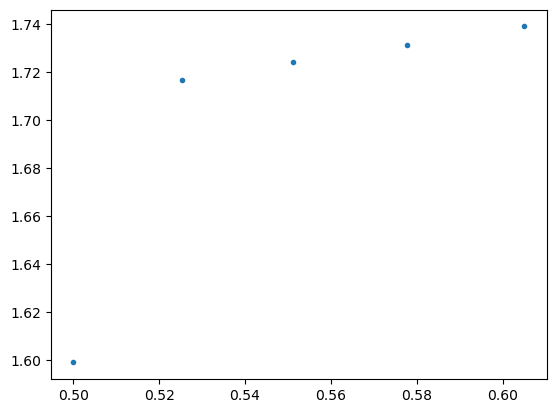

In [66]:
plt.plot(g0s**2/(omega*U),totalnumberofelectrons_LB[0],".")

In [17]:
totalnumberofelectrons_LB

array([[0.60116113, 0.60177679, 0.60241466, 0.60307203, 0.6037461 ,
        0.60443398, 0.60513334, 1.22880507, 1.23135801, 1.23397428,
        1.23664804, 1.23937359, 1.24214564, 1.24495835, 1.2478087 ,
        1.25069322, 1.25360954, 1.90129944, 1.99141927, 1.99297468]])

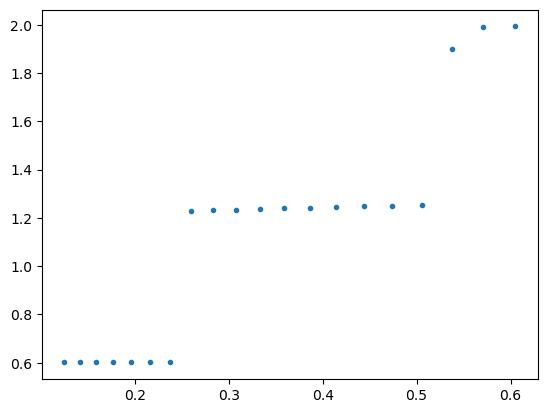

In [23]:

plt.plot(g0s**2/(omega*U),totalnumberofelectrons_LB[0],".")

In [ ]:
# Save arrays
np.savez("allegutendatenzusammen.npz", 
         double_occu_A=double_occu_A, 
         double_occu_B=double_occu_B, 
         phonon_numb_A=phonon_numb_A, 
         phonon_numb_B=phonon_numb_B, 
         CC_single_tube_A=CC_single_tube_A, 
         CC_single_tube_B=CC_single_tube_B, 
         Var_pho_A=Var_pho_A,
         Var_pho_B=Var_pho_B,
         Entangled_entropy=Entangled_entropy,
         MI_phonons=MI_phonons, 
         negativity=negativity)